# Forecasting Healthcare Call Demand Under Structural Breaks
**Author:** Allison M. Schiltz

---

##  Project Overview
- **Problem:** Define healthcare "surge" (demand) vs "strain" (system failure/complaints).
- **Dataset:** The ["Healthcare Call Data Analysis During Emergency Times"](https://www.kaggle.com/datasets/shuvokumarbasak2030/healthcare-call-data-analysis-duringemergencytimes) dataset (Kaggle), sourced from the [Health Portal Dashboard](https://16263.dghs.gov.bd/report/report.php) operated by the Bangladesh government which spans 2016–2025 and includes multiple distinct emergency events.


## 0. Environment & Imports

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import numpy as np
from importlib.metadata import version
import sys

packages = ["pandas", "matplotlib", "seaborn", "statsmodels", "numpy"]
for p in packages:
    print(f"{p}: {version(p)}")

print(f"Environment: {sys.version}")

pandas: 2.3.3
matplotlib: 3.10.7
seaborn: 0.13.2
statsmodels: 0.14.4
numpy: 2.3.4
Environment: 3.11.9 (main, Jun  5 2025, 11:28:29) [Clang 17.0.0 (clang-1700.0.13.5)]


## 1. Load Raw Data

In [14]:
# Load the data
df_raw = pd.read_csv('../data/raw/daily_and_month_call_report.csv')

## 2. Initial Inspection

In [15]:
print('HEAD:\n', df_raw.head())
print('\nTAIL:\n', df_raw.tail())
print('\nSAMPLE:\n', df_raw.sample(n=5, random_state=42))
print('\nSHAPE:\n', df_raw.shape)
print('\nINFO:')
df_raw.info()
print('\nDESCRIBE:\n', df_raw.describe().T)
print('\nNULL COUNTS:\n', df_raw.isnull().sum().sort_values(ascending=False))

HEAD:
    Year Month  Total Number of Calls  Total Number of Doctors Consultancy  \
0  2025   Feb                 155200                                98964   
1  2025   Jan                 130982                                87815   
2  2024   Dec                 133725                                86832   
3  2024   Nov                 153698                                93710   
4  2024   Oct                 214604                               108207   

   Number of Total Health Information  Number of Total Ambulance Information  \
0                                3777                                   5773   
1                                3217                                   4179   
2                                3634                                   3735   
3                                3010                                   4421   
4                                6307                                   5792   

   Number of Total Complaints  Number of Calls To

## 3. Draft Data Dictionary (from raw)

In [20]:
# Build a concise data dictionary for the raw dataset
data_dictionary = pd.DataFrame([
    {
        "raw_column": "Year",
        "description": "Calendar year of the observation.",
        "example_or_unit": "2019"
    },
    {
        "raw_column": "Month",
        "description": "Month label used with Year to form the monthly date.",
        "example_or_unit": "Jan, Feb, ..."
    },
    {
        "raw_column": "Total Number of Calls",
        "description": "Total inbound calls received by the healthcare service.",
        "example_or_unit": "Count of calls"
    },
    {
        "raw_column": "Total Number of Doctors Consultancy",
        "description": "Calls that resulted in doctor consultation.",
        "example_or_unit": "Count of consult calls"
    },
    {
        "raw_column": "Number of Total Health Information",
        "description": "Calls requesting general health information.",
        "example_or_unit": "Count of information calls"
    },
    {
        "raw_column": "Number of Total Ambulance Information",
        "description": "Calls requesting ambulance-related information.",
        "example_or_unit": "Count of information calls"
    },
    {
        "raw_column": "Number of Total Complaints",
        "description": "Calls logged as complaints (system strain proxy).",
        "example_or_unit": "Count of complaint calls"
    },
    {
        "raw_column": "Number of Calls To Know About The Service",
        "description": "Calls asking about available services.",
        "example_or_unit": "Count of service inquiry calls"
    }
])

data_dictionary["raw_dtype"] = data_dictionary["raw_column"].map(df_raw.dtypes.astype(str))
data_dictionary["unique_values"] = data_dictionary["raw_column"].map(df_raw.nunique(dropna=True))

display(data_dictionary[["raw_column", "raw_dtype", "unique_values", "description", "example_or_unit"]])

,raw_column,raw_dtype,unique_values,description,example_or_unit
0,Year,int64,10,Calendar year of the observation.,2019
1,Month,object,12,Month label used with Year to form the monthly...,"Jan, Feb, ..."
2,Total Number of Calls,int64,107,Total inbound calls received by the healthcare...,Count of calls
3,Total Number of Doctors Consultancy,int64,106,Calls that resulted in doctor consultation.,Count of consult calls
4,Number of Total Health Information,int64,107,Calls requesting general health information.,Count of information calls
5,Number of Total Ambulance Information,int64,107,Calls requesting ambulance-related information.,Count of information calls
6,Number of Total Complaints,int64,107,Calls logged as complaints (system strain proxy).,Count of complaint calls
7,Number of Calls To Know About The Service,int64,107,Calls asking about available services.,Count of service inquiry calls


## 4. Data Quality Audit

### 4.1 Missingness
- No missing data

In [ ]:
# Check for missing values -- NaN or None
missing = pd.concat([df_raw_raw.isnull().sum(), 100 * df_raw.isnull().mean()], axis=1)
missing.columns=['count', '%']
missing.sort_values(by='count', ascending=False)

,count,%
Year,0,0.0
Month,0,0.0
Total Number of Calls,0,0.0
Total Number of Doctors Consultancy,0,0.0
Number of Total Health Information,0,0.0
Number of Total Ambulance Information,0,0.0
Number of Total Complaints,0,0.0
Number of Calls To Know About The Service,0,0.0


In [23]:
# Check for blank or whitespace-only strings in object columns
for col in df_raw.select_dtypes(include='object'):
    n_blanks = (df_raw[col].str.strip() == '').sum()
    if n_blanks > 0:
        print(f"{col}: {n_blanks} blank/whitespace values")
    else:
        print(f"{col}: No blank/whitespace values")

Month: No blank/whitespace values


In [24]:
# Check for placeholder values
placeholders = ['NA', 'N/A', 'null', 'None', '?', '-']
for col in df_raw.columns:
    for val in placeholders:
        n = (df_raw[col] == val).sum()
        if n > 0:
            print(f"{col}: {n} occurrences of '{val}'")

In [25]:
# Check for constant columns
for col in df_raw.columns:
    if df_raw[col].nunique(dropna=False) == 1:
        print(f"{col} has only one unique value: {df_raw[col].unique()}")

### 4.2 Duplicates

In [26]:
# number unique values
df_raw.nunique()

Year                                          10
Month                                         12
Total Number of Calls                        107
Total Number of Doctors Consultancy          106
Number of Total Health Information           107
Number of Total Ambulance Information        107
Number of Total Complaints                   107
Number of Calls To Know About The Service    107
dtype: int64

In [27]:
# Find duplicate rows
duplicates = df_raw[df_raw.duplicated()]

# Display duplicate rows (if any)
print(duplicates)

# Count duplicate rows
print(df_raw.duplicated().sum())

Empty DataFrame
Columns: [Year, Month, Total Number of Calls, Total Number of Doctors Consultancy, Number of Total Health Information, Number of Total Ambulance Information, Number of Total Complaints, Number of Calls To Know About The Service]
Index: []
0


In [33]:
# View unique values per column
for col in df_raw.columns:
    if df_raw[col].nunique() < 13:
        print(df_raw[col].value_counts(), "\n")

Year
2024    12
2023    12
2019    12
2022    12
2021    12
2020    12
2017    12
2018    12
2016     9
2025     2
Name: count, dtype: int64 

Month
Feb     9
Jan     9
Dec     9
Nov     9
Oct     9
Sept    9
Aug     9
July    9
June    9
May     9
Apr     9
Mar     8
Name: count, dtype: int64 



### 4.3 Data Types and Conversion

In [ ]:
# Standardize month names
month_map = {
    "jan": "Jan", "january": "Jan",
    "feb": "Feb", "february": "Feb",
    "mar": "Mar", "march": "Mar",
    "apr": "Apr", "april": "Apr",
    "may": "May",
    "jun": "Jun", "june": "Jun",
    "jul": "Jul", "july": "Jul",
    "aug": "Aug", "august": "Aug",
    "sep": "Sep", "sept": "Sep", "september": "Sep",
    "oct": "Oct", "october": "Oct",
    "nov": "Nov", "november": "Nov",
    "dec": "Dec", "december": "Dec",
}

m = (
    df_raw["Month"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(".", "", regex=False)
)

df_raw["Month"] = m.map(month_map)

# Validate: fail fast if any month didn't map
if df_raw["Month"].isna().any():
    bad = df_raw.loc[df_raw["Month"].isna(), "Month"]
    raise ValueError(f"Unmapped month values found: {bad.unique()}")


In [17]:
df_raw['Month'].unique()

array(['Feb', 'Jan', 'Dec', 'Nov', 'Oct', 'Sept', 'Aug', 'July', 'June',
       'May', 'Apr', 'Mar'], dtype=object)

In [35]:
# Create datetime object
df_raw["Date"] = pd.to_datetime(
    df_raw["Year"].astype(str) + "-" + df_raw["Month"],
    format="%Y-%b",
    errors="raise"
)

In [40]:
# Set Date as index and sort oldest to newest
df_raw.set_index('Date', inplace=True)
df_raw.sort_index(inplace=True)

### 4.4 Numeric Ranges & Impossible Values

In [36]:
# 1) Numeric range (percentiles) — good for understanding bounds
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns
print("NUMERIC SUMMARY (extended percentiles)")
display(df_raw[numeric_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T)

# 2) Impossible values: negatives catch data entry errors
negatives_any = (df_raw[numeric_cols] < 0).any()
bad_negative_cols = negatives_any[negatives_any].index.tolist()
print("Numeric columns with any negative values:", bad_negative_cols if bad_negative_cols else "None")

NUMERIC SUMMARY (extended percentiles)


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Year,107.0,2020.205607,2.601662,2016.0,2016.00,2016.0,2018.0,2020.0,2022.0,2024.0,2024.94,2025.0
Total Number of Calls,107.0,234031.626168,369700.080656,51432.0,66093.62,73060.6,99188.5,142400.0,202552.0,486810.4,2018940.82,2329457.0
Total Number of Doctors Consultancy,107.0,154455.345794,268135.135666,38162.0,38598.42,47919.9,60818.0,94893.0,121526.5,296852.6,1518947.18,1703100.0
Number of Total Health Information,107.0,15714.728972,23104.165341,3010.0,3177.52,3936.9,6858.0,10841.0,13291.0,41286.8,108082.92,173306.0
Number of Total Ambulance Information,107.0,9240.317757,15330.680874,220.0,335.08,383.8,836.0,4734.0,8658.5,46649.2,63046.16,91751.0
Number of Total Complaints,107.0,6924.457944,10484.201602,77.0,295.98,362.5,697.0,4133.0,8262.0,24394.2,49833.52,59760.0
Number of Calls To Know About The Service,107.0,47509.102804,61227.797516,4075.0,9222.10,11099.1,18536.5,28895.0,45822.5,150202.2,317248.08,342434.0


Numeric columns with any negative values: None


In [41]:
# 3) Temporal continuity: check for gaps in the time series
expected_dates = pd.date_range(start=df_raw.index.min(), end=df_raw.index.max(), freq='MS')
missing_dates = expected_dates.difference(df_raw.index)
print(f"\nTemporal continuity: {len(missing_dates)} missing months")
if len(missing_dates) > 0:
    print("Missing dates (first 10):")
    print(missing_dates.tolist()[:10])


Temporal continuity: 0 missing months


In [46]:
# 4) Logical consistency: do call components make sense relative to total?
components = ['Total Number of Doctors Consultancy',
       'Number of Total Health Information',
       'Number of Total Ambulance Information', 'Number of Total Complaints',
       'Number of Calls To Know About The Service']
df_raw['sum_components'] = df_raw[components].sum(axis=1)

inconsistent = df_raw[df_raw['sum_components'] > df_raw['Total Number of Calls']]
print(f"\nLogical consistency: {len(inconsistent)} rows where component sums exceed total_calls")
if len(inconsistent) > 0:
    print("Rows with component sum > total:")
    display(inconsistent[['total_calls', 'sum_components'] + components])

# Clean up temporary column
df_raw.drop(columns=['sum_components'], inplace=True)


Logical consistency: 0 rows where component sums exceed total_calls


## 5. Data Cleaning & Transformation

In [ ]:
# Drop redundant columns and rename columns for clarity
df = df_raw.copy()
df.drop(columns=['Year', 'Month'], inplace=True)
df.rename(columns={
    'Total Number of Calls': 'total_calls',
    'Total Number of Doctors Consultancy': 'total_doctor_consults',
    'Number of Total Health Information': 'health_info',
    'Number of Total Ambulance Information': 'ambulance_info',
    'Number of Total Complaints': 'complaints',
    'Number of Calls To Know About The Service': 'service_info'
}, inplace=True)

print("Cleaned dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst few rows:")
df.head()

Cleaned dataset shape: (107, 6)

Column names:
['total_calls', 'total_doctor_consults', 'health_info', 'ambulance_info', 'complaints', 'service_info']

First few rows:


,total_calls,total_doctor_consults,health_info,ambulance_info,complaints,service_info
Date,,,,,,
2016-04-01,51432,43885,3175,220,77,4075
2016-05-01,166635,137326,12118,925,439,15827
2016-06-01,186433,152580,14887,856,473,17637
2016-07-01,145061,116686,11831,922,404,15218
2016-08-01,142400,112831,12184,980,340,16065


## 6. Exploratory Data Analysis

In [48]:
# Basic statistics on cleaned data
print("SUMMARY STATISTICS")
print(df.describe().T)

SUMMARY STATISTICS
                       count           mean            std      min      25%  \
total_calls            107.0  234031.626168  369700.080656  51432.0  99188.5   
total_doctor_consults  107.0  154455.345794  268135.135666  38162.0  60818.0   
health_info            107.0   15714.728972   23104.165341   3010.0   6858.0   
ambulance_info         107.0    9240.317757   15330.680874    220.0    836.0   
complaints             107.0    6924.457944   10484.201602     77.0    697.0   
service_info           107.0   47509.102804   61227.797516   4075.0  18536.5   

                            50%       75%        max  
total_calls            142400.0  202552.0  2329457.0  
total_doctor_consults   94893.0  121526.5  1703100.0  
health_info             10841.0   13291.0   173306.0  
ambulance_info           4734.0    8658.5    91751.0  
complaints               4133.0    8262.0    59760.0  
service_info            28895.0   45822.5   342434.0  


In [49]:
# Pairwise correlations
print("\nPAIRWISE CORRELATIONS")
corr_matrix = df.corr()
print(corr_matrix)


PAIRWISE CORRELATIONS
                       total_calls  total_doctor_consults  health_info  \
total_calls               1.000000               0.994481     0.924721   
total_doctor_consults     0.994481               1.000000     0.904190   
health_info               0.924721               0.904190     1.000000   
ambulance_info            0.891041               0.848324     0.820058   
complaints                0.871245               0.827180     0.836434   
service_info              0.962238               0.930864     0.899339   

                       ambulance_info  complaints  service_info  
total_calls                  0.891041    0.871245      0.962238  
total_doctor_consults        0.848324    0.827180      0.930864  
health_info                  0.820058    0.836434      0.899339  
ambulance_info               1.000000    0.933792      0.946049  
complaints                   0.933792    1.000000      0.917892  
service_info                 0.946049    0.917892      1.00000

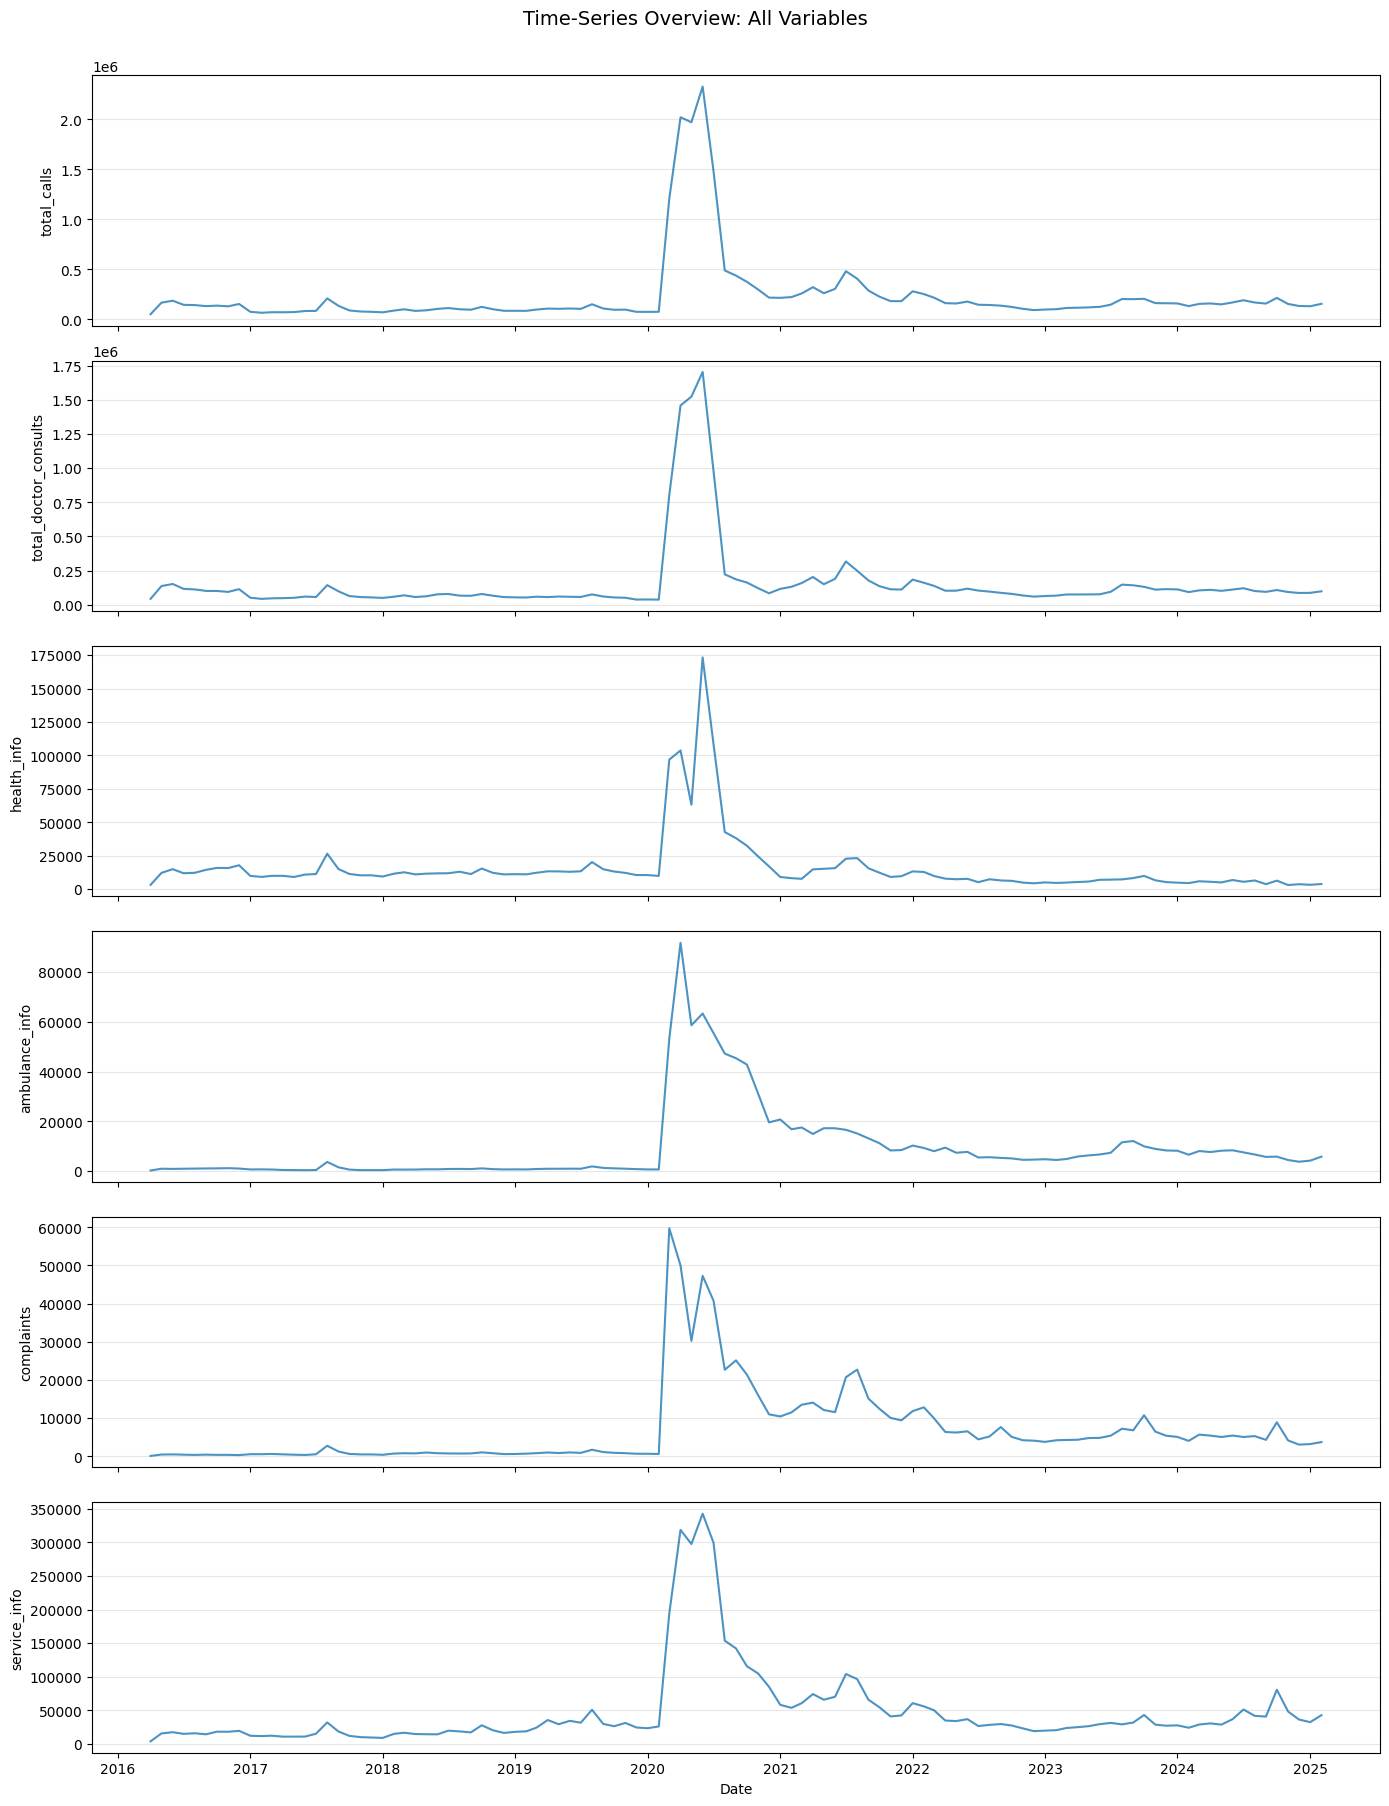

In [50]:
# Time-series overview: all variables
fig, axes = plt.subplots(len(df.columns), 1, figsize=(14, 3*len(df.columns)), sharex=True)

for idx, col in enumerate(df.columns):
    axes[idx].plot(df.index, df[col], linewidth=1.5, alpha=0.8)
    axes[idx].set_ylabel(col, fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)

plt.xlabel('Date')
plt.suptitle('Time-Series Overview: All Variables', fontsize=14, y=1.001)
plt.tight_layout()
plt.show()

### 6.2 Regime Comparison: Pre-COVID vs During-COVID

In [51]:
# Split into pre-COVID and during-COVID periods
pre_covid = df.loc[:'2020-02-01']
during_covid = df.loc['2020-03-01':]

print("PRE-COVID STATISTICS (2016-Feb 2020)")
print(pre_covid.describe().T)
print(f"\nCalls-Complaints correlation: {pre_covid['total_calls'].corr(pre_covid['complaints']):.3f}")

PRE-COVID STATISTICS (2016-Feb 2020)
                       count           mean           std      min      25%  \
total_calls             47.0  103897.382979  33056.240896  51432.0  80686.5   
total_doctor_consults   47.0   70376.191489  27943.483768  38162.0  53888.0   
health_info             47.0   12376.446809   3363.438547   3175.0  10666.5   
ambulance_info          47.0     839.297872    521.000622    220.0    601.0   
complaints              47.0     699.808511    414.466112     77.0    471.0   
service_info            47.0   19605.638298   8760.223321   4075.0  14515.0   

                           50%       75%       max  
total_calls            97104.0  118628.5  209179.0  
total_doctor_consults  59498.0   78041.0  152580.0  
health_info            11831.0   13241.0   26461.0  
ambulance_info           768.0     938.5    3649.0  
complaints               641.0     797.0    2741.0  
service_info           17637.0   24588.0   50963.0  

Calls-Complaints correlation: 0.451


In [52]:
print("DURING-COVID STATISTICS (Mar 2020–present)")
print(during_covid.describe().T)
print(f"\nCalls-Complaints correlation: {during_covid['total_calls'].corr(during_covid['complaints']):.3f}")

print("\n" + "="*60)
print("SUMMARY: Correlation shift")
print("="*60)
print(f"Pre-COVID:  {pre_covid['total_calls'].corr(pre_covid['complaints']):.3f}")
print(f"During-COVID: {during_covid['total_calls'].corr(during_covid['complaints']):.3f}")

DURING-COVID STATISTICS (Mar 2020–present)
                       count           mean            std      min  \
total_calls             60.0  335970.116667  469731.086415  92283.0   
total_doctor_consults   60.0  220317.350000  344264.869695  60055.0   
health_info             60.0   18329.716667   30567.683066   3010.0   
ambulance_info          60.0   15821.116667   17938.279182   3735.0   
complaints              60.0   11800.433333   11929.080574   3035.0   
service_info            60.0   69366.816667   74627.587542  19249.0   

                             25%       50%        75%        max  
total_calls            146472.00  179709.0  265885.75  2329457.0  
total_doctor_consults   94597.25  112494.5  159796.00  1703100.0  
health_info              5262.50    7344.0   14852.25   173306.0  
ambulance_info           5825.00    8272.5   16621.75    91751.0  
complaints               4980.25    6663.0   12546.25    59760.0  
service_info            29018.75   41530.5   67020.25   3

### 6.3 Identified Emergency Events & Periods

Emergency events are defined from external, documented sources rather than inferred from the data. This avoids circular reasoning when later testing whether call volume and complaints respond to these events.

**Sources used to define event windows:**
- **2019 Dengue Outbreak**: Bangladesh's DGHS reported its largest dengue burden on record in 2019, with cases rising sharply from July and peaking in August–September 2019. (Source: WHO Bangladesh / DGHS)
- **COVID-19 Wave 1**: First confirmed case in Bangladesh March 8, 2020 (WHO). National lockdown declared March 26, 2020. Cases declined through late 2020.
- **COVID-19 Delta Wave**: The Delta variant drove Bangladesh's most severe wave, with daily cases peaking in late July–August 2021. (Source: IEDCR Bangladesh / Our World in Data)

In [ ]:
# Event windows are anchored to externally documented dates, not derived from this data.
# This is intentional: we want to test whether the data responds to known events,
# not define events by looking at the data first (which would be circular).

events = {
    # Bangladesh DGHS: dengue cases rose sharply from July 2019, peaked Aug-Sep, subsided by Nov
    ('2019-07-01', '2019-11-01'): 'Dengue Outbreak 2019',
    # WHO: first BD case Mar 8, 2020; national lockdown Mar 26, 2020; cases declined late 2020
    ('2020-03-01', '2020-12-01'): 'COVID-19 Wave 1',
    # IEDCR Bangladesh: Delta wave peaked Jul-Aug 2021
    ('2021-06-01', '2021-09-01'): 'COVID-19 Delta Wave',
}

print("EMERGENCY EVENTS (externally sourced)")
print("=" * 50)
for (start, end), label in events.items():
    event_data = df.loc[start:end, 'total_calls']
    avg_calls = event_data.mean()
    max_calls = event_data.max()
    baseline = df.loc[:'2019-06-01', 'total_calls'].mean()
    pct_above = (avg_calls - baseline) / baseline * 100
    print(f"\n{label} ({start} to {end})")
    print(f"  Average calls : {avg_calls:,.0f}")
    print(f"  Peak calls    : {max_calls:,.0f}")
    print(f"  vs. pre-event baseline: {pct_above:+.1f}%")
    print(f"  Duration      : {len(event_data)} months")


IDENTIFIED EMERGENCY EVENTS

Dengue Outbreak 2019 (2019-07-01 to 2019-11-01)
  Average calls: 111271
  Peak calls: 150908
  Duration: 5 months

COVID-19 Wave 1 (2020-03-01 to 2020-12-31)
  Average calls: 1082837
  Peak calls: 2329457
  Duration: 10 months

COVID-19 Wave (Delta) (2021-06-01 to 2021-09-01)
  Average calls: 370273
  Peak calls: 481426
  Duration: 4 months


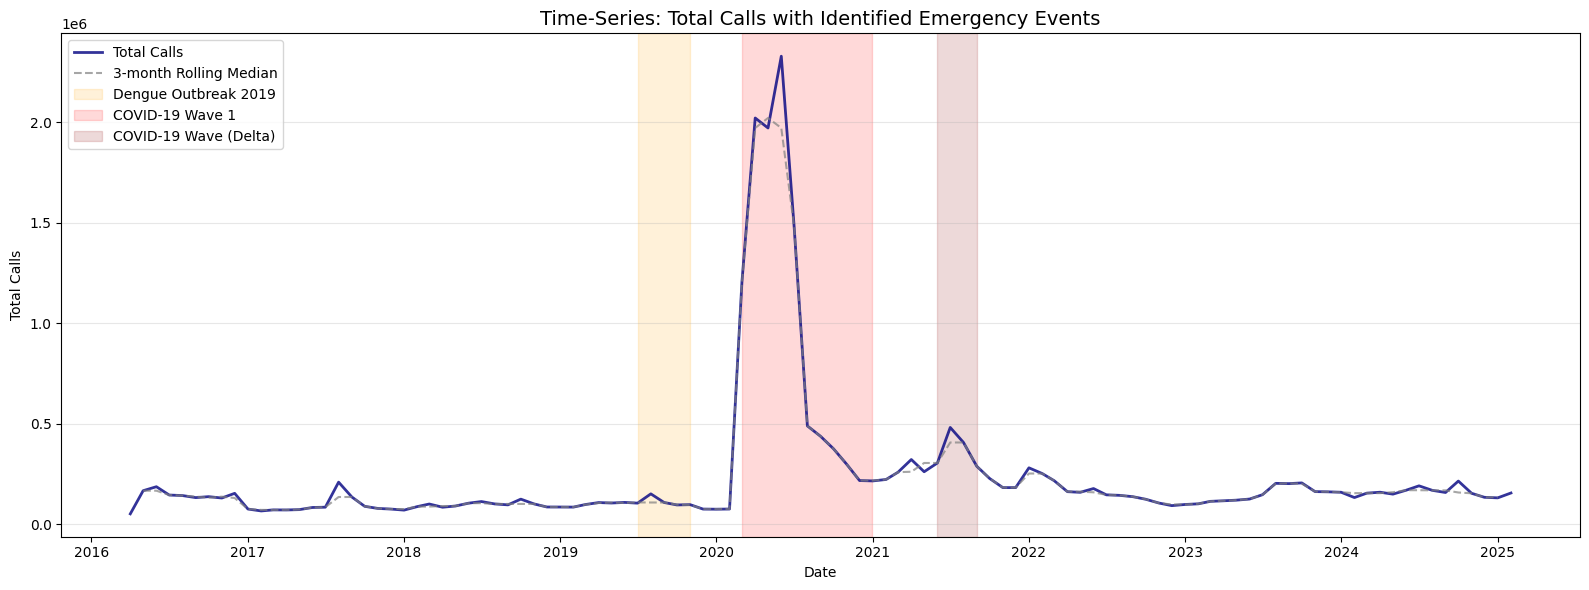


These events are candidates for detailed demand-strain analysis.


In [54]:
# Visualize time-series with annotated events
plt.figure(figsize=(16, 6))
plt.plot(df.index, df['total_calls'], linewidth=2, label='Total Calls', color='navy', alpha=0.8)
plt.plot(df.index, rolling_median, linewidth=1.5, linestyle='--', label='3-month Rolling Median', 
         color='gray', alpha=0.7)

# Color each event period differently
colors = ['orange', 'red', 'darkred']
for (start, end), label, color in zip(events.keys(), events.values(), colors):
    plt.axvspan(start, end, color=color, alpha=0.15, label=label)

plt.title('Time-Series: Total Calls with Identified Emergency Events', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Total Calls')
plt.legend(loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nThese events are candidates for detailed demand-strain analysis.")


### Signal vs. Strain
We're starting by looking at the 2019 dengue outbreak, as opposed to the COVID-19 outbreak, because it was a typical outbreak with a clear beginning, peak, and end. It makes a good test case to see if there is temporal lag. COVID-19, on the other hand, lasted for years and involved multiple waves. 

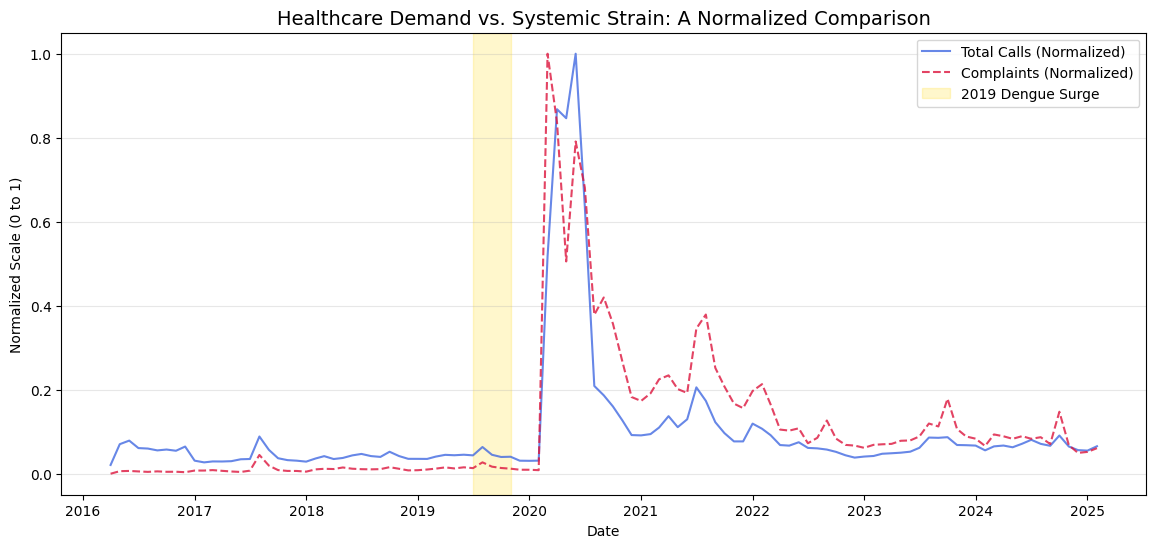

In [14]:

plt.figure(figsize=(14, 6))

# Normalizing to see the relationship clearly between total calls and complaints
plt.plot(df.index, df['total_calls'] / df['total_calls'].max(), 
         label='Total Calls (Normalized)', color='royalblue', alpha=0.8)
plt.plot(df.index, df['complaints'] / df['complaints'].max(), 
         label='Complaints (Normalized)', color='crimson', linestyle='--', alpha=0.8)

# Highlight the 2019 Dengue period
plt.axvspan('2019-07-01', '2019-11-01', color='gold', alpha=0.2, label='2019 Dengue Surge')

plt.title('Healthcare Demand vs. Systemic Strain: A Normalized Comparison', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Normalized Scale (0 to 1)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

*No obvious lag is apparent in the comparison plot of calls and complaints, so we'll zoom in.*

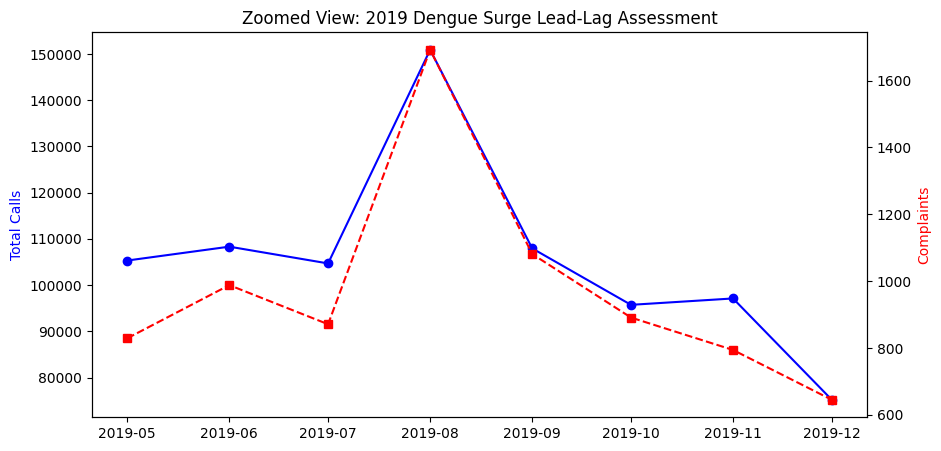

In [15]:
# Zooming in on the 2019 Dengue Outbreak
dengue_surge = df.loc['2019-05-01':'2019-12-01']

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(dengue_surge.index, dengue_surge['total_calls'], color='blue', marker='o', label='Calls')
ax1.set_ylabel('Total Calls', color='blue')

ax2 = ax1.twinx()
ax2.plot(dengue_surge.index, dengue_surge['complaints'], color='red', marker='s', label='Complaints', linestyle='--')
ax2.set_ylabel('Complaints', color='red')

plt.title('Zoomed View: 2019 Dengue Surge Lead-Lag Assessment')
plt.show()

*It still doesn't look like there is a lag. Next we'll use cross-correlation to confirm that the lag is actually 0.*

In [16]:
# Calculate Cross-Correlation between Calls and Complaints
# 'lags=6' looks at a 6-month window
ccf_values = sm.tsa.stattools.ccf(df['complaints'], df['total_calls'], adjusted=False)

# Print the first few lags
for i in range(5):
    print(f"Correlation at Lag {i}: {ccf_values[i]:.3f}")

Correlation at Lag 0: 0.871
Correlation at Lag 1: 0.717
Correlation at Lag 2: 0.598
Correlation at Lag 3: 0.514
Correlation at Lag 4: 0.376


*The highest correlation is at Lag 0, suggesting that systemic complaints rise contemporaneously with call volume. This indicates that the infrustructure experiences immediate pressure during public health emergencies, rather than a delayed effect, when using a 1-month resolution.* 

In [17]:
# Calculate Cross-Correlation between Doctor Consults and Complaints
# 'lags=6' looks at a 6-month window
ccf_values = sm.tsa.stattools.ccf(df['complaints'], df['total_doctor_consults'], adjusted=False)

# Print the first few lags
for i in range(5):
    print(f"Correlation at Lag {i}: {ccf_values[i]:.3f}")

Correlation at Lag 0: 0.827
Correlation at Lag 1: 0.689
Correlation at Lag 2: 0.576
Correlation at Lag 3: 0.487
Correlation at Lag 4: 0.352


*Checked complaints against doctor consults in case the lag is hidden in the noise of total calls. However, the pattern of correlations is similar to total calls.*

In [18]:
# Check if calls lag complaints (negative shift)
for i in range(-3, 1):
    corr = df['complaints'].corr(df['total_calls'].shift(i))
    print(f"Correlation at Lag {i}: {corr:.3f}")

Correlation at Lag -3: 0.482
Correlation at Lag -2: 0.628
Correlation at Lag -1: 0.791
Correlation at Lag 0: 0.871


*Checked for negative lag, but because the correlation coefficient peaks perfectly at Lag 0 (0.871) and drops as you move away in either direction (positive or negative), we have clear statistical evidence that demand and strain are contemporaneous at the monthly level.*

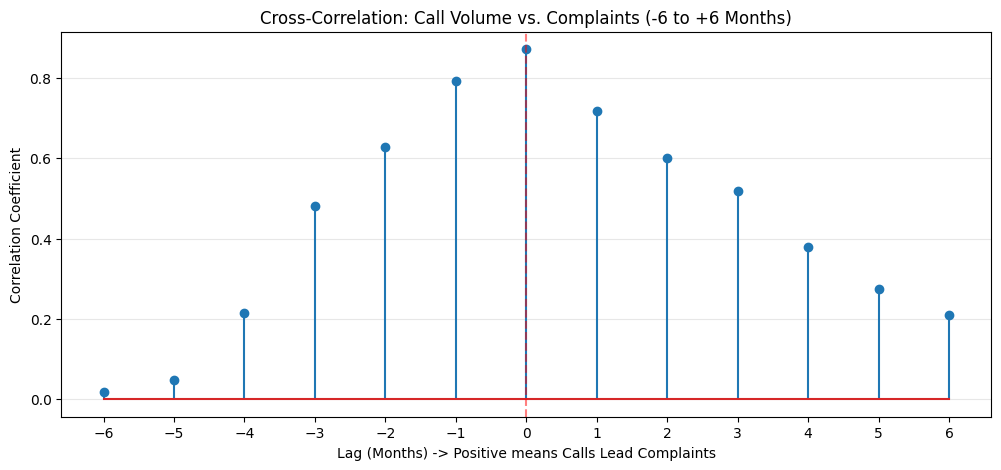

Lag -6: 0.018
Lag -5: 0.047
Lag -4: 0.216
Lag -3: 0.482
Lag -2: 0.628
Lag -1: 0.791
Lag 0: 0.871
Lag 1: 0.718
Lag 2: 0.601
Lag 3: 0.518
Lag 4: 0.379
Lag 5: 0.274
Lag 6: 0.208


In [19]:
# Calculate CCF for both positive and negative lags

lags = np.arange(-6, 7)
corrs = []

for lag in lags:
    # Shift the 'total_calls' series and correlate with 'complaints'
    c = df['complaints'].corr(df['total_calls'].shift(lag))
    corrs.append(c)

# Plot the CCF
plt.figure(figsize=(12, 5))
plt.stem(lags, corrs)
plt.axvline(0, color='red', linestyle='--', alpha=0.5) # The Zero Line
plt.title('Cross-Correlation: Call Volume vs. Complaints (-6 to +6 Months)')
plt.xlabel('Lag (Months) -> Positive means Calls Lead Complaints')
plt.ylabel('Correlation Coefficient')
plt.xticks(lags)
plt.grid(axis='y', alpha=0.3)
plt.show()

# Print results for documentation
for lag, corr in zip(lags, corrs):
    print(f"Lag {lag}: {corr:.3f}")

*The significant correlation at negative lags (e.g., Lag -1: 0.791) suggests that systemic strain begins to manifest during the initial uptick of a surge, rather than only at the peak. However, the global maximum at Lag 0 confirms that the strongest alignment between demand and strain occurs contemporaneously within the same monthly window.*

### Structural Break Analysis

In [20]:
# Create a 'Pre-COVID' and 'During-COVID' slice
pre_covid = df.loc[:'2020-02-01']
during_covid = df.loc['2020-03-01':'2022-12-01']

print(f"Pre-COVID Correlation: {pre_covid['total_calls'].corr(pre_covid['complaints']):.3f}")
print(f"During-COVID Correlation: {during_covid['total_calls'].corr(during_covid['complaints']):.3f}")

Pre-COVID Correlation: 0.451
During-COVID Correlation: 0.867


In [21]:
# Decompose both total calls and complaints to isolate the "shocks" (residuals)
res_calls = seasonal_decompose(df['total_calls'], model='additive').resid.dropna()
res_comp = seasonal_decompose(df['complaints'], model='additive').resid.dropna()

# Check correlation of the "shocks" only
print(f"Residual Correlation: {res_calls.corr(res_comp):.3f}")

Residual Correlation: 0.787


*The residual correlation is very strong, meaning...*

    - The Magnitude: Since 1.0 is a perfect 1-to-1 match, 0.787 means that nearly 80% of the "unpredictable" spikes in calls are mirrored exactly by a spike in complaints.
    - The Timing (Lag 0): This means the complaints aren't waiting for the surge to finish. They are happening in the same month the surge begins.
    - The Conclusion: In a healthy system, you might see a small surge and a delayed or low correlation in complaints because the system has a buffer, such as extra staff. In this data, the high correlation at Lag 0 proves there is no buffer. The system is likely already at its limit, so any "shock" translates instantly into a failure in service quality.

In [22]:
# Check stationarity of the complaints time series

def check_stationarity(series):
    result = adfuller(series)
    print(f'ADF Statistic: {result[0]:.3f}')
    print(f'p-value: {result[1]:.3f}')

check_stationarity(df['total_calls'])
check_stationarity(df['complaints'])

ADF Statistic: -2.235
p-value: 0.194
ADF Statistic: -3.008
p-value: 0.034


In [23]:
# Create a differenced series
df['calls_diff'] = df['total_calls'].diff().dropna()

# Check stationarity again
check_stationarity(df['calls_diff'].dropna())

ADF Statistic: -5.669
p-value: 0.000


In [24]:
# Create a 'Pre-COVID' and 'During-COVID' slice
pre_covid = df.loc[:'2020-02-01']
during_covid = df.loc['2020-03-01':'2022-12-01']

print(f"Pre-COVID Correlation: {pre_covid['total_calls'].corr(pre_covid['complaints']):.3f}")
print(f"During-COVID Correlation: {during_covid['total_calls'].corr(during_covid['complaints']):.3f}")

Pre-COVID Correlation: 0.451
During-COVID Correlation: 0.867


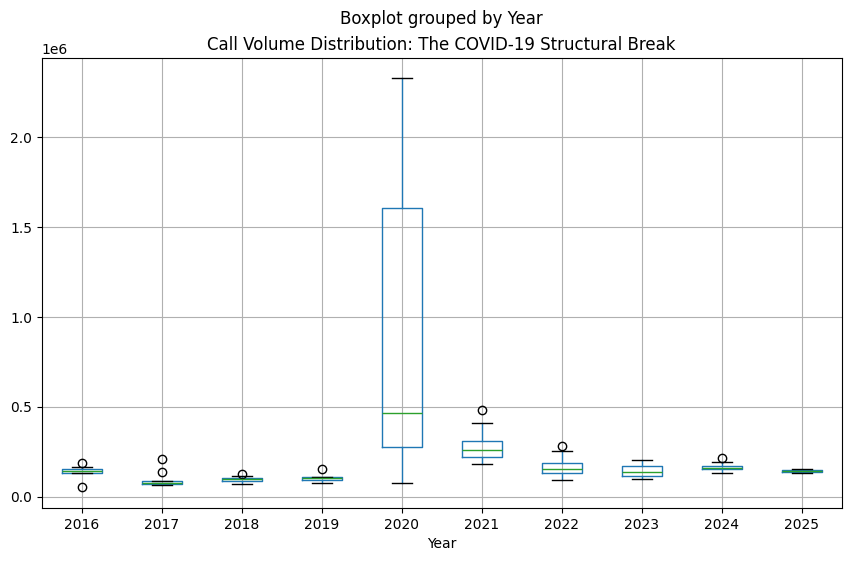

In [25]:
# Boxplot of call volume by year

df['Year'] = df.index.year
df.boxplot(column='total_calls', by='Year', figsize=(10,6))
plt.title('Call Volume Distribution: The COVID-19 Structural Break')
plt.show()

### **Summary of Statistical Findings: Demand vs. Strain**

| Metric | Value | Interpretation |
| :--- | :--- | :--- |
| **Total Correlation** | 0.871 | Strong overall alignment of demand and strain across the 10-year period. |
| **Residual Correlation** | 0.787 | High correlation of "unpredictable shocks," indicating immediate system pressure. |
| **Peak Lag** | 0 | Both predictable and unpredictable events trigger contemporaneous strain. |
| **Stationarity (Calls)** | p = 0.000 | Achieved stationarity through first-order differencing ($d=1$). |